In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
baseDP = pd.read_csv("C:/Users/conta/Desktop/Projeto-Dash-PY-JS/BaseDPEvolucaoMensalCisp.csv", sep=";", encoding='Latin1')
'''Aisp_Regiao = pd.read_csv("C:/Users/conta/Desktop/Projeto-Dash-PY-JS/AispPorRegiao.csv", sep=";", encoding='Latin1')
RISP_AISP_CISP = pd.read_csv("C:/Users/conta/Desktop/Projeto-Dash-PY-JS/Relacao_RISPxAISPxCISP.csv", sep=";", encoding='Latin1')'''

'Aisp_Regiao = pd.read_csv("C:/Users/conta/Desktop/Projeto-Dash-PY-JS/AispPorRegiao.csv", sep=";", encoding=\'Latin1\')\nRISP_AISP_CISP = pd.read_csv("C:/Users/conta/Desktop/Projeto-Dash-PY-JS/Relacao_RISPxAISPxCISP.csv", sep=";", encoding=\'Latin1\')'

In [ ]:
baseDP.isna().sum()

cisp                         0
mes                          0
ano                          0
mes_ano                      0
aisp                         0
                            ..
encontro_ossada              0
pol_militares_mortos_serv    0
pol_civis_mortos_serv        0
registro_ocorrencias         0
fase                         0
Length: 63, dtype: int64

In [8]:
baseDP.head(10)

,cisp,mes,ano,mes_ano,aisp,risp,munic,mcirc,regiao,hom_doloso,...,estelionato,apreensao_drogas,recuperacao_veiculos,ameaca,pessoas_desaparecidas,encontro_cadaver,encontro_ossada,pol_militares_mortos_serv,pol_civis_mortos_serv,registro_ocorrencias
0,1,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,0,...,69,1,5,21,2,0,0,0,0,578
1,4,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,3,...,1,35,7,15,6,0,1,0,0,441
2,5,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,3,...,37,4,10,47,2,1,0,0,0,637
3,6,1,2003,2003m01,1,1,Rio de Janeiro,3304557,Capital,6,...,8,20,77,26,2,1,0,0,0,473
4,7,1,2003,2003m01,1,1,Rio de Janeiro,3304557,Capital,4,...,4,3,9,10,1,3,0,0,0,147
5,9,1,2003,2003m01,2,1,Rio de Janeiro,3304557,Capital,1,...,20,11,20,36,3,0,0,0,0,554
6,10,1,2003,2003m01,2,1,Rio de Janeiro,3304557,Capital,1,...,19,7,19,40,2,3,0,0,0,593
7,12,1,2003,2003m01,19,1,Rio de Janeiro,3304557,Capital,2,...,18,11,6,48,3,0,0,0,0,620
8,13,1,2003,2003m01,19,1,Rio de Janeiro,3304557,Capital,0,...,15,14,14,26,1,0,0,0,0,455
9,14,1,2003,2003m01,23,1,Rio de Janeiro,3304557,Capital,0,...,16,10,12,43,2,2,0,0,0,636


In [7]:
baseDP = baseDP.drop(columns=['fase', 'posse_drogas', 'trafico_drogas', 'apreensao_drogas_sem_autor', 'apf', 'aaapai', 'cmp', 'cmba', 'roubo_bicicleta'])

In [31]:
baseDP.describe()

,cisp,aisp,risp,mcirc,hom_doloso,lesao_corp_morte,latrocinio,cvli,hom_por_interv_policial,letalidade_violenta,...,apreensao_drogas,recuperacao_veiculos,ameaca,pessoas_desaparecidas,encontro_cadaver,encontro_ossada,pol_militares_mortos_serv,pol_civis_mortos_serv,registro_ocorrencias,data
count,35670.000000,35670.00000,35670.000000,3.567000e+04,35670.000000,35670.000000,35670.000000,35670.000000,35670.000000,35670.000000,...,35670.000000,35670.000000,35670.000000,35670.000000,35670.000000,35670.000000,35670.000000,35670.000000,35670.000000,35670
mean,81.722652,20.11797,3.870003,3.794171e+06,2.982759,0.027754,0.097421,3.107934,0.624194,3.732128,...,11.374236,14.090692,41.214606,3.193832,0.364116,0.023017,0.013709,0.002159,437.366470,2014-02-21 13:10:00.100925184
min,1.000000,1.00000,1.000000,3.300100e+06,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2003-01-01 00:00:00
25%,38.000000,10.00000,2.000000,3.302601e+06,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,3.000000,1.000000,14.000000,0.000000,0.000000,0.000000,0.000000,0.000000,105.000000,2008-09-01 00:00:00
50%,78.000000,20.00000,4.000000,3.304557e+06,1.000000,0.000000,0.000000,1.000000,0.000000,2.000000,...,7.000000,4.000000,30.000000,2.000000,0.000000,0.000000,0.000000,0.000000,366.000000,2014-04-01 00:00:00
75%,125.000000,30.00000,6.000000,3.304557e+06,4.000000,0.000000,0.000000,4.000000,0.000000,5.000000,...,14.000000,16.000000,56.000000,5.000000,0.000000,0.000000,0.000000,0.000000,655.000000,2019-08-01 00:00:00
max,168.000000,43.00000,7.000000,9.999999e+06,43.000000,6.000000,9.000000,43.000000,27.000000,52.000000,...,348.000000,359.000000,370.000000,191.000000,112.000000,10.000000,4.000000,2.000000,3185.000000,2025-01-01 00:00:00
std,48.319201,11.34058,2.011672,1.744792e+06,4.387304,0.178816,0.370733,4.503734,1.567720,5.310973,...,14.855155,24.709499,39.419745,4.135065,1.002127,0.181738,0.132509,0.048190,391.721209,NaN


In [13]:
Roubos_agrupamentos = baseDP.groupby(['roubo_apos_saque', 'roubo_transeunte', 'roubo_celular', 'roubo_em_coletivo', 'roubo_rua', 'roubo_veiculo', 'roubo_carga', 'roubo_comercio', 'roubo_residencia', 'roubo_banco', 'roubo_cx_eletronico', 'roubo_conducao_saque', 'outros_roubos']).sum()
furtos_agrupamentos = baseDP.groupby(['furto_veiculos', 'furto_transeunte', 'furto_coletivo', 'furto_celular', 'furto_bicicleta', 'outros_furtos']).sum()

In [28]:
baseDP['ano'] = baseDP['ano'].astype(str)


In [32]:
baseDP.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35670 entries, 0 to 35669
Data columns (total 55 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   cisp                       35670 non-null  int64         
 1   mes                        35670 non-null  object        
 2   ano                        35670 non-null  object        
 3   mes_ano                    35670 non-null  object        
 4   aisp                       35670 non-null  int64         
 5   risp                       35670 non-null  int64         
 6   munic                      35670 non-null  object        
 7   mcirc                      35670 non-null  int64         
 8   regiao                     35670 non-null  object        
 9   hom_doloso                 35670 non-null  int64         
 10  lesao_corp_morte           35670 non-null  int64         
 11  latrocinio                 35670 non-null  int64         
 12  cvli

In [ ]:
baseDP['ano'] = pd.to_datetime(baseDP['ano'], format='%Y')
baseDP.head()

,cisp,mes,ano,mes_ano,aisp,risp,munic,mcirc,regiao,hom_doloso,...,apreensao_drogas,recuperacao_veiculos,ameaca,pessoas_desaparecidas,encontro_cadaver,encontro_ossada,pol_militares_mortos_serv,pol_civis_mortos_serv,registro_ocorrencias,data
0,1,1,2003-01-01,2003m01,5,1,Rio de Janeiro,3304557,Capital,0,...,1,5,21,2,0,0,0,0,578,2003-01-01
1,4,1,2003-01-01,2003m01,5,1,Rio de Janeiro,3304557,Capital,3,...,35,7,15,6,0,1,0,0,441,2003-01-01
2,5,1,2003-01-01,2003m01,5,1,Rio de Janeiro,3304557,Capital,3,...,4,10,47,2,1,0,0,0,637,2003-01-01
3,6,1,2003-01-01,2003m01,1,1,Rio de Janeiro,3304557,Capital,6,...,20,77,26,2,1,0,0,0,473,2003-01-01
4,7,1,2003-01-01,2003m01,1,1,Rio de Janeiro,3304557,Capital,4,...,3,9,10,1,3,0,0,0,147,2003-01-01


In [ ]:
baseDP['mes_ano'] = baseDP['mes_ano'].str.replace('m', '-')

baseDP.head()

,cisp,mes,ano,mes_ano,aisp,risp,munic,mcirc,regiao,hom_doloso,...,apreensao_drogas,recuperacao_veiculos,ameaca,pessoas_desaparecidas,encontro_cadaver,encontro_ossada,pol_militares_mortos_serv,pol_civis_mortos_serv,registro_ocorrencias,data
0,1,1,2003-01-01,2003-01,5,1,Rio de Janeiro,3304557,Capital,0,...,1,5,21,2,0,0,0,0,578,2003-01-01
1,4,1,2003-01-01,2003-01,5,1,Rio de Janeiro,3304557,Capital,3,...,35,7,15,6,0,1,0,0,441,2003-01-01
2,5,1,2003-01-01,2003-01,5,1,Rio de Janeiro,3304557,Capital,3,...,4,10,47,2,1,0,0,0,637,2003-01-01
3,6,1,2003-01-01,2003-01,1,1,Rio de Janeiro,3304557,Capital,6,...,20,77,26,2,1,0,0,0,473,2003-01-01
4,7,1,2003-01-01,2003-01,1,1,Rio de Janeiro,3304557,Capital,4,...,3,9,10,1,3,0,0,0,147,2003-01-01


In [39]:
baseDP = baseDP.drop(columns='mes_ano')

In [49]:
baseDP_reduzido = baseDP.head(500)

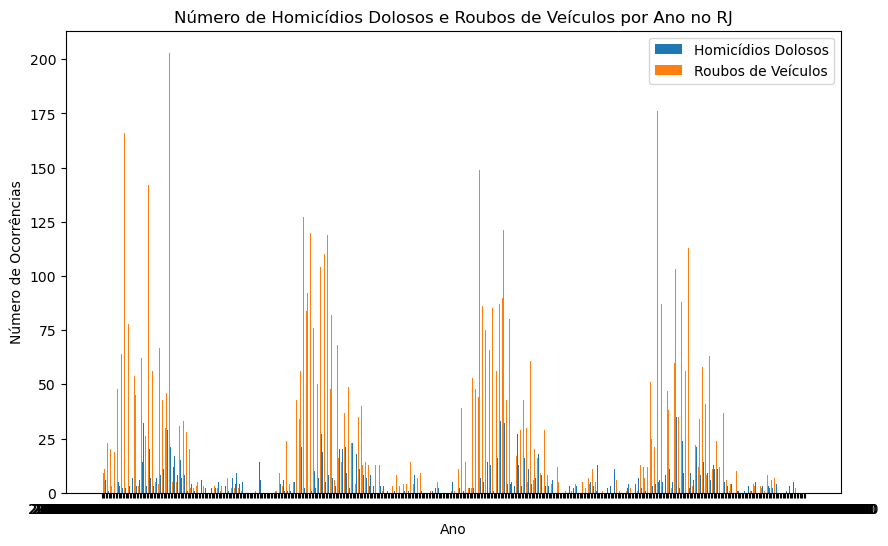

In [ ]:
fig = plt.figure(figsize=(10, 6))

bar_width = 0.35

r1 = np.arange(len(baseDP_reduzido['ano']))
r2 = [x + bar_width for x in r1]

plt.bar(r1, baseDP_reduzido['hom_doloso'], width=bar_width, label='Homicídios Dolosos')
plt.bar(r2, baseDP_reduzido['roubo_veiculo'], width=bar_width, label='Roubos de Veículos')

plt.title('Número de Homicídios Dolosos e Roubos de Veículos por Ano no RJ')
plt.xlabel('Ano')
plt.ylabel('Número de Ocorrências')
plt.xticks([r + bar_width / 2 for r in range(len(baseDP_reduzido['ano']))], baseDP_reduzido['ano'])
plt.legend(loc='upper right')

plt.show()

In [42]:
del furtos_agrupamentos, Roubos_agrupamentos

TypeError: 'str' object is not callable

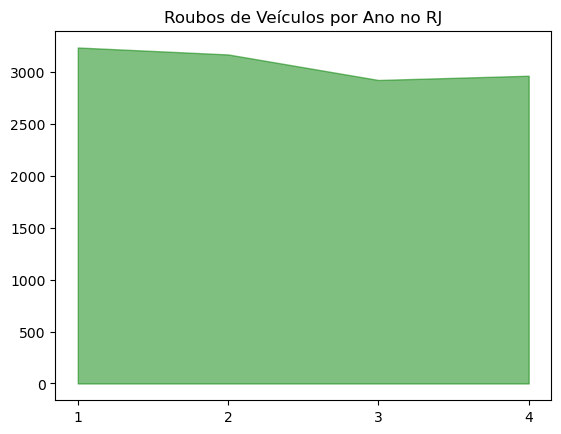

In [66]:
plt.fill_between(baseDP_reduzido.groupby('mes')['mes'].first(), baseDP_reduzido.groupby('mes')['roubo_veiculo'].sum(), color='green', alpha=0.5)

plt.title('Roubos de Veículos por Ano no RJ')
plt.xlabel('Quartil')
plt.ylabel('Número de Veículos Roubados')
plt.legend(['Roubos de Veículos'])

plt.show()

TypeError: 'str' object is not callable

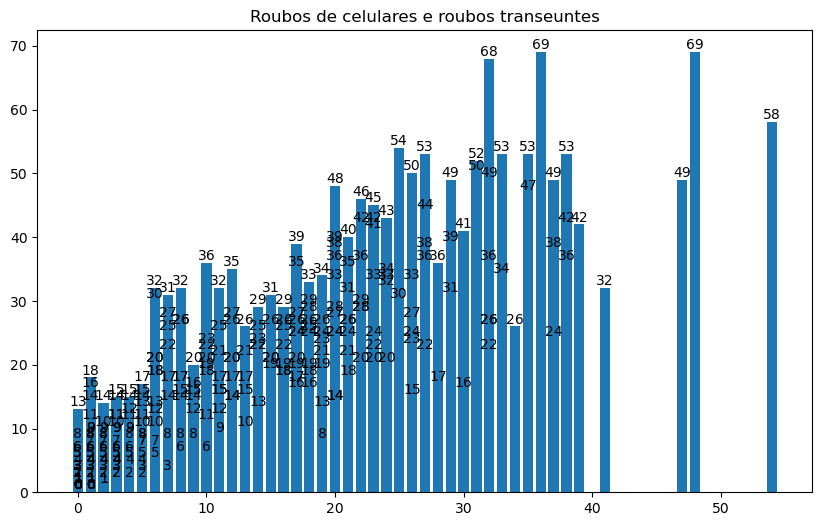

In [72]:
fig = plt.figure(figsize=(10, 6))

# Criação do gráfico de barras
bars = plt.bar(baseDP_reduzido['roubo_celular'], baseDP_reduzido['roubo_transeunte'])

# Adiciona rótulos às barras
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 2), ha='center', va='bottom')

plt.title('Roubos de celulares e roubos transeuntes')
plt.xlabel('Roubos de Celulares')
plt.ylabel('Roubos Transeuntes')

plt.show()

In [ ]:
df = pd.DataFrame(data)

cores = ['#FF7F50', '#6A5ACD']

# Criação da figura e eixos com tamanho personalizado
fig, ax = plt.subplots(figsize=(10, 5))

# Plotar gráfico de área com cores suaves e transparentes
df.plot(x='Data', y=['Vendas', 'Lucro'], kind='area', color=cores, alpha=0.5, ax=ax)

# Personalizar o gráfico
ax.set_title('Análise de Séries Temporais')
ax.set_xlabel('Data')
ax.set_ylabel('Valores')

# Mostrar o gráfico
plt.show()


In [ ]:
baseDP.to_csv('baseDP_modificado.csv', index=False)